# Funciones de utilidad

In [38]:
!gdown 1WjW-XOSAoVoLtYS7gwDXgDt6iG2vnZNA

Downloading...
From: https://drive.google.com/uc?id=1WjW-XOSAoVoLtYS7gwDXgDt6iG2vnZNA
To: /content/IMG_demo.jpeg
100% 1.41M/1.41M [00:00<00:00, 139MB/s]


In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [40]:
img = cv2.imread('IMG_demo.jpeg')[:,:,::-1]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

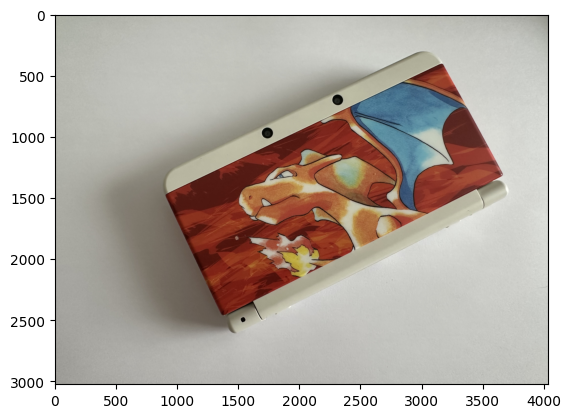

In [41]:
plt.imshow(img)

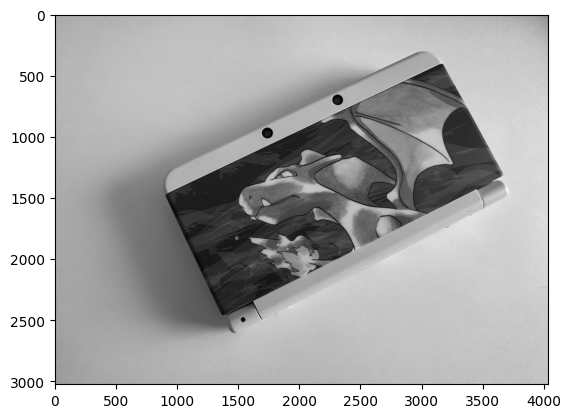

In [42]:
plt.imshow(gray, cmap = 'gray')

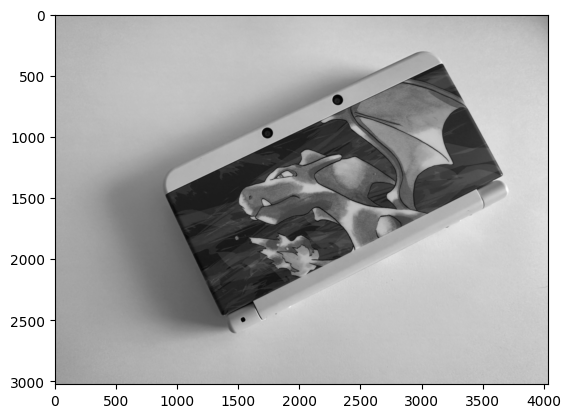

In [43]:
plt.imshow(blur, cmap = 'gray')

In [44]:
edges = cv2.Canny(blur, 50, 150)

In [45]:
edges

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [46]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contours = sorted(contours, key=cv2.contourArea, reverse=True)

for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

    if len(approx) == 4:
        sheet = approx
        break

In [47]:
pts = sheet.reshape(4,2)

In [48]:
pts

array([[2413,  931],
       [2737, 1210],
       [2787, 1367],
       [2737, 1209]], dtype=int32)